 Lendo o arquivo: deputies_dataset.csv...
 Arquivo carregado com sucesso!

---  Tipos de Dados (Note que datas estão como 'object') ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3014902 entries, 0 to 3014901
Data columns (total 10 columns):
 #   Column                          Dtype  
---  ------                          -----  
 0   bugged_date                     int64  
 1   receipt_date                    object 
 2   deputy_id                       int64  
 3   political_party                 object 
 4   state_code                      object 
 5   deputy_name                     object 
 6   receipt_social_security_number  float64
 7   receipt_description             object 
 8   establishment_name              object 
 9   receipt_value                   int64  
dtypes: float64(1), int64(3), object(6)
memory usage: 230.0+ MB


None

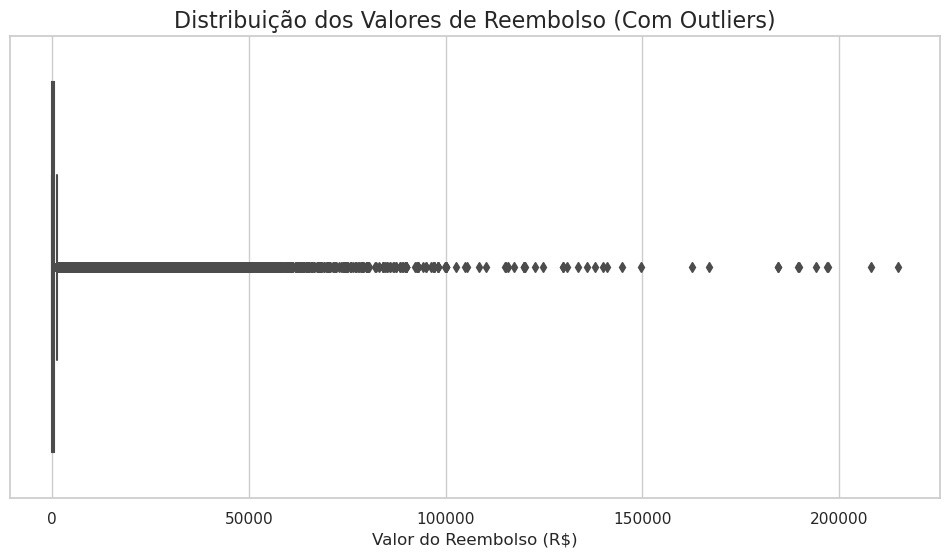

 OBSERVAÇÃO: Note como existem pontos isolados com valores absurdamente altos à direita.
Isso distorce a análise e será tratado na camada Silver.

---  Os 5 Maiores Reembolsos (Suspeita de Fraude/Erro) ---


,deputy_name,political_party,receipt_value,receipt_description
1479100,Arnaldo Faria De Sá,PTB,215000,Dissemination of the Parliamentary Activity.
390710,Arnaldo Faria De Sá,PTB,208320,Dissemination of the Parliamentary Activity.
34364,Arnaldo Faria De Sá,PTB,197370,Dissemination of the Parliamentary Activity.
724095,Arnaldo Faria De Sá,PTB,197000,Dissemination of the Parliamentary Activity.
723750,Arlindo Chinaglia,PT,194100,Dissemination of the Parliamentary Activity.



--- Contagem de Valores Nulos por Coluna ---


receipt_social_security_number    520952
dtype: int64

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração para os gráficos ficarem bonitos
sns.set_theme(style="whitegrid")

# 1. CARGA DOS DADOS (BRUTOS)
# Vamos ler o arquivo principal onde estão os gastos
caminho = 'deputies_dataset.csv' # Como o notebook está na pasta raw, o caminho é direto
print(f" Lendo o arquivo: {caminho}...")

try:
    df = pd.read_csv(caminho)
    print(" Arquivo carregado com sucesso!")
except FileNotFoundError:
    print(" Erro: Arquivo não encontrado. Verifique se ele está na mesma pasta deste notebook.")

# 2. ANÁLISE DE TIPOS DE DADOS (O primeiro "Erro")
# O professor quer ver que as datas e valores estão como texto (object) e não numero/data
print("\n---  Tipos de Dados (Note que datas estão como 'object') ---")
display(df.info())

# 3. CAÇANDO OUTLIERS (O "Gráfico Feio")
# Vamos converter a coluna de valor para número só para conseguir plotar o erro
# (Sem limpar de verdade, só forçando a conversão para ver o problema)
df['receipt_value_plot'] = pd.to_numeric(df['receipt_value'], errors='coerce')

plt.figure(figsize=(12, 6))
plt.title("Distribuição dos Valores de Reembolso (Com Outliers)", fontsize=16)

# Boxplot é o melhor gráfico para mostrar outliers (aqueles pontos pretos fora da caixa)
sns.boxplot(x=df['receipt_value_plot'])
plt.xlabel("Valor do Reembolso (R$)")
plt.show()

print(" OBSERVAÇÃO: Note como existem pontos isolados com valores absurdamente altos à direita.")
print("Isso distorce a análise e será tratado na camada Silver.")

# 4. OLHANDO OS EXTREMOS (Top 5 Mais Caros)
print("\n---  Os 5 Maiores Reembolsos (Suspeita de Fraude/Erro) ---")
maiores_gastos = df.nlargest(5, 'receipt_value_plot')[['deputy_name', 'political_party', 'receipt_value', 'receipt_description']]
display(maiores_gastos)

# 5. ANÁLISE DE NULOS (Buracos nos dados)
print("\n--- Contagem de Valores Nulos por Coluna ---")
nulos = df.isnull().sum()
display(nulos[nulos > 0])